In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt

from rabl.machine_learning.bagging_ensemble import (
    run_bagging_ensemble,
    plot_ensemble_forecast_profile_grid,
)


SCALED_H5_PATH = Path(r"../outputs/datasets/scaled_split/lstm_merged_batches_0003_k12_minmax_train0.70_val0.15_test0.15.h5")
OUT_DIR = Path(r"../outputs/ml_results/bagging_ensemble_3_N501")

In [2]:
results = run_bagging_ensemble(
    scaled_h5_path=SCALED_H5_PATH,
    out_dir=OUT_DIR,
    n_models=3,
    bag_fraction=0.85,
    seed=123,

    batch_size=512,
    epochs=50,
    learning_rate=3e-4,
    step_lr_step_size=30,
    step_lr_gamma=0.5,

    n_lstm=1,
    lstm_hidden=64,
    lstm_dropout=0.3,
    n_fc=1,
    fc_hidden=(384,),

    early_stopping_patience=10,
    early_stopping_min_delta=0.0,

    prefer_gpu=True,
    verbose=1,
)

results

[bagging] configured n_models=3, bag_fraction=0.850, total_train_profiles=700, total_train_samples=350700, profiles_per_bag=595
[bagging] saved venn diagram: ../outputs/ml_results/bagging_ensemble_3_N501/bagged_dataset_bag_overlap_venn.png
[bagging] bag_0: profiles=595 unique_profiles=595 samples=298095 shared_across_all_bags=442 bag_only_profiles=20
[bagging] bag_1: profiles=595 unique_profiles=595 samples=298095 shared_across_all_bags=442 bag_only_profiles=20
[bagging] bag_2: profiles=595 unique_profiles=595 samples=298095 shared_across_all_bags=442 bag_only_profiles=13


KeyboardInterrupt: 

In [3]:
bagged_h5_path = Path(results["bagged_h5_path"])
forecast_h5_path = Path(results["forecast_output_path"])

print("Bagged dataset:", bagged_h5_path, "exists?", bagged_h5_path.exists())
print("Forecasts HDF5 :", forecast_h5_path, "exists?", forecast_h5_path.exists())

for i, model_dir in enumerate(results["model_dirs"]):
    model_path = Path(model_dir) / "model.pt"
    print(f"Model {i} weights:", model_path, "exists?", model_path.exists())

Bagged dataset: ../outputs/ml_results/bagging_ensemble_3_N501/bagged_dataset.h5 exists? True
Forecasts HDF5 : ../outputs/ml_results/bagging_ensemble_3_N501/rolling_forecasts.h5 exists? True
Model 0 weights: ../outputs/ml_results/bagging_ensemble_3_N501/model_0/model.pt exists? True
Model 1 weights: ../outputs/ml_results/bagging_ensemble_3_N501/model_1/model.pt exists? True
Model 2 weights: ../outputs/ml_results/bagging_ensemble_3_N501/model_2/model.pt exists? True


Num forecast profiles: 150
Plotting: ['results_drum_profile_02004', 'results_drum_profile_02006', 'results_drum_profile_02007', 'results_drum_profile_02025', 'results_drum_profile_02028']


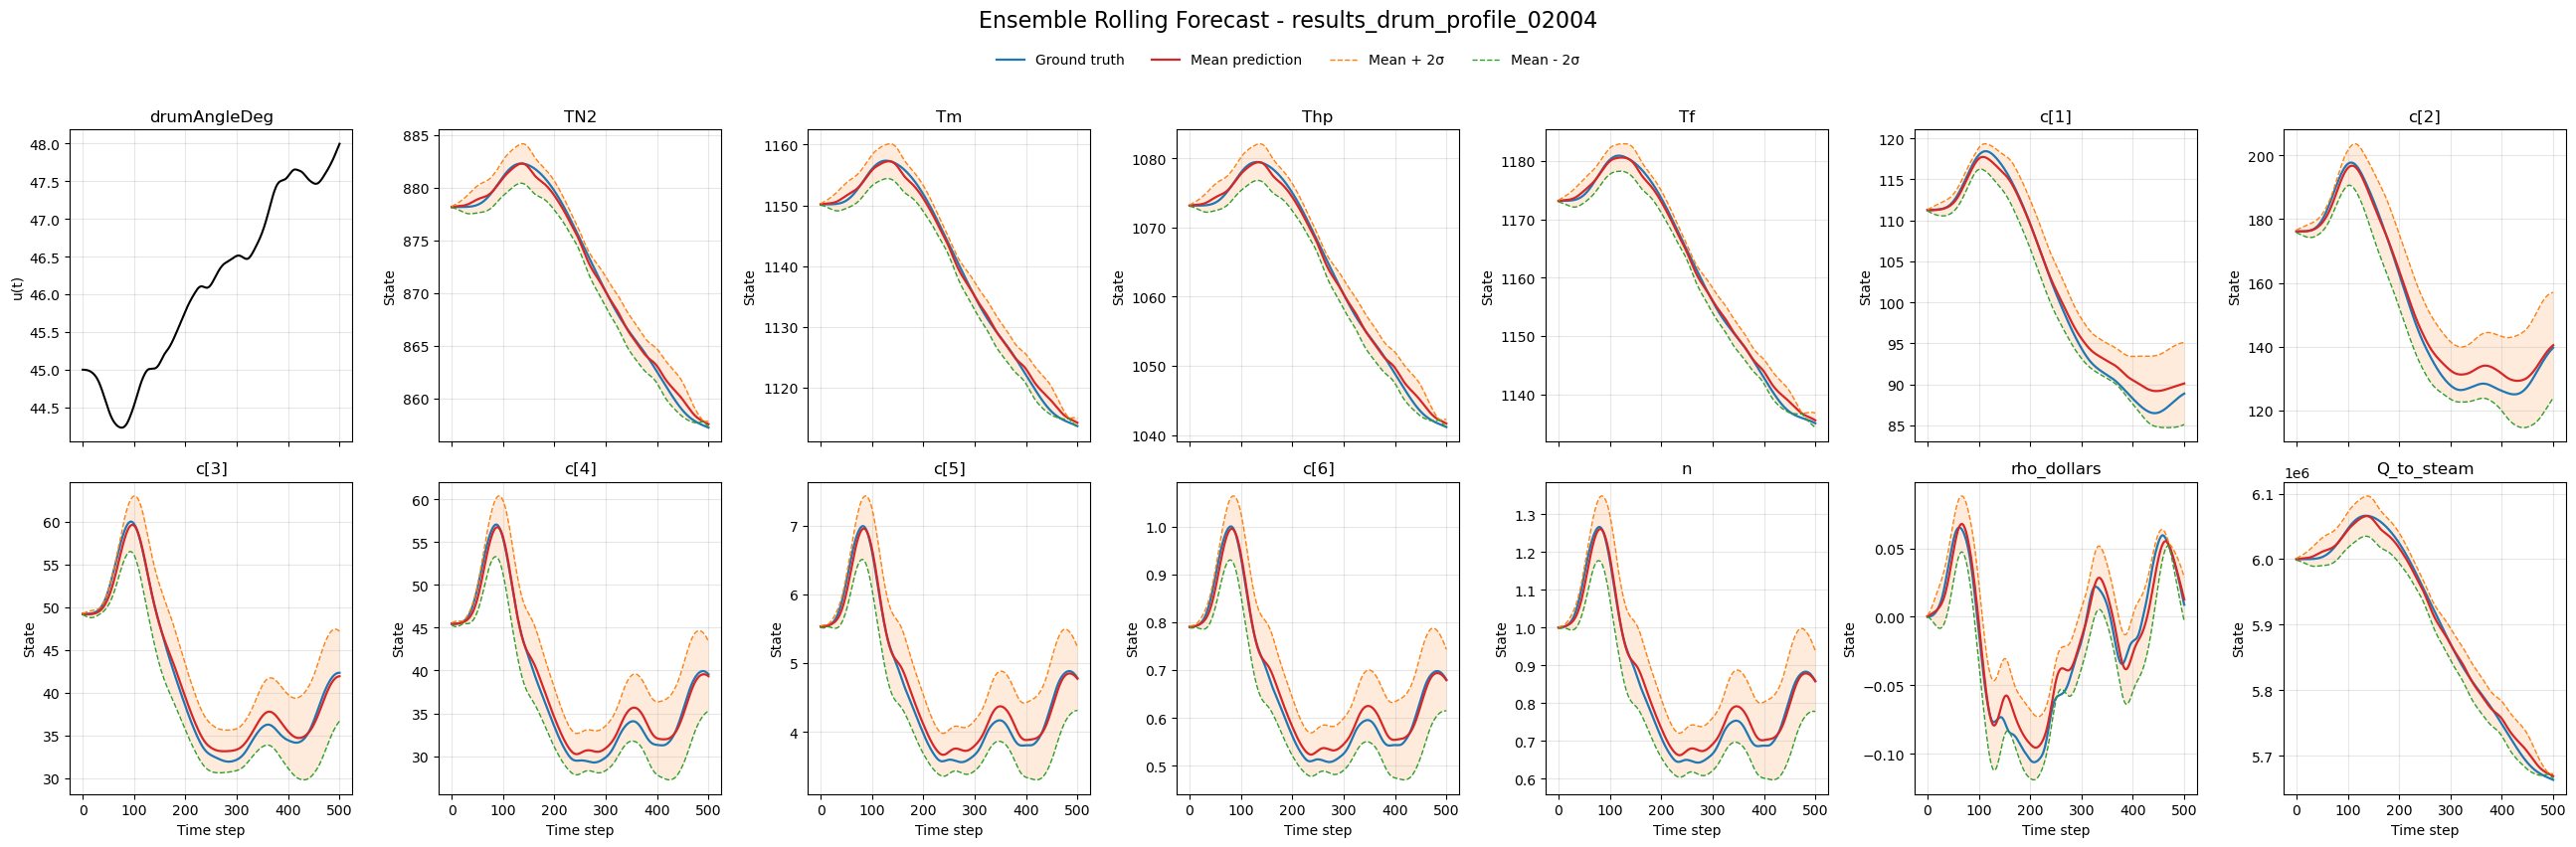

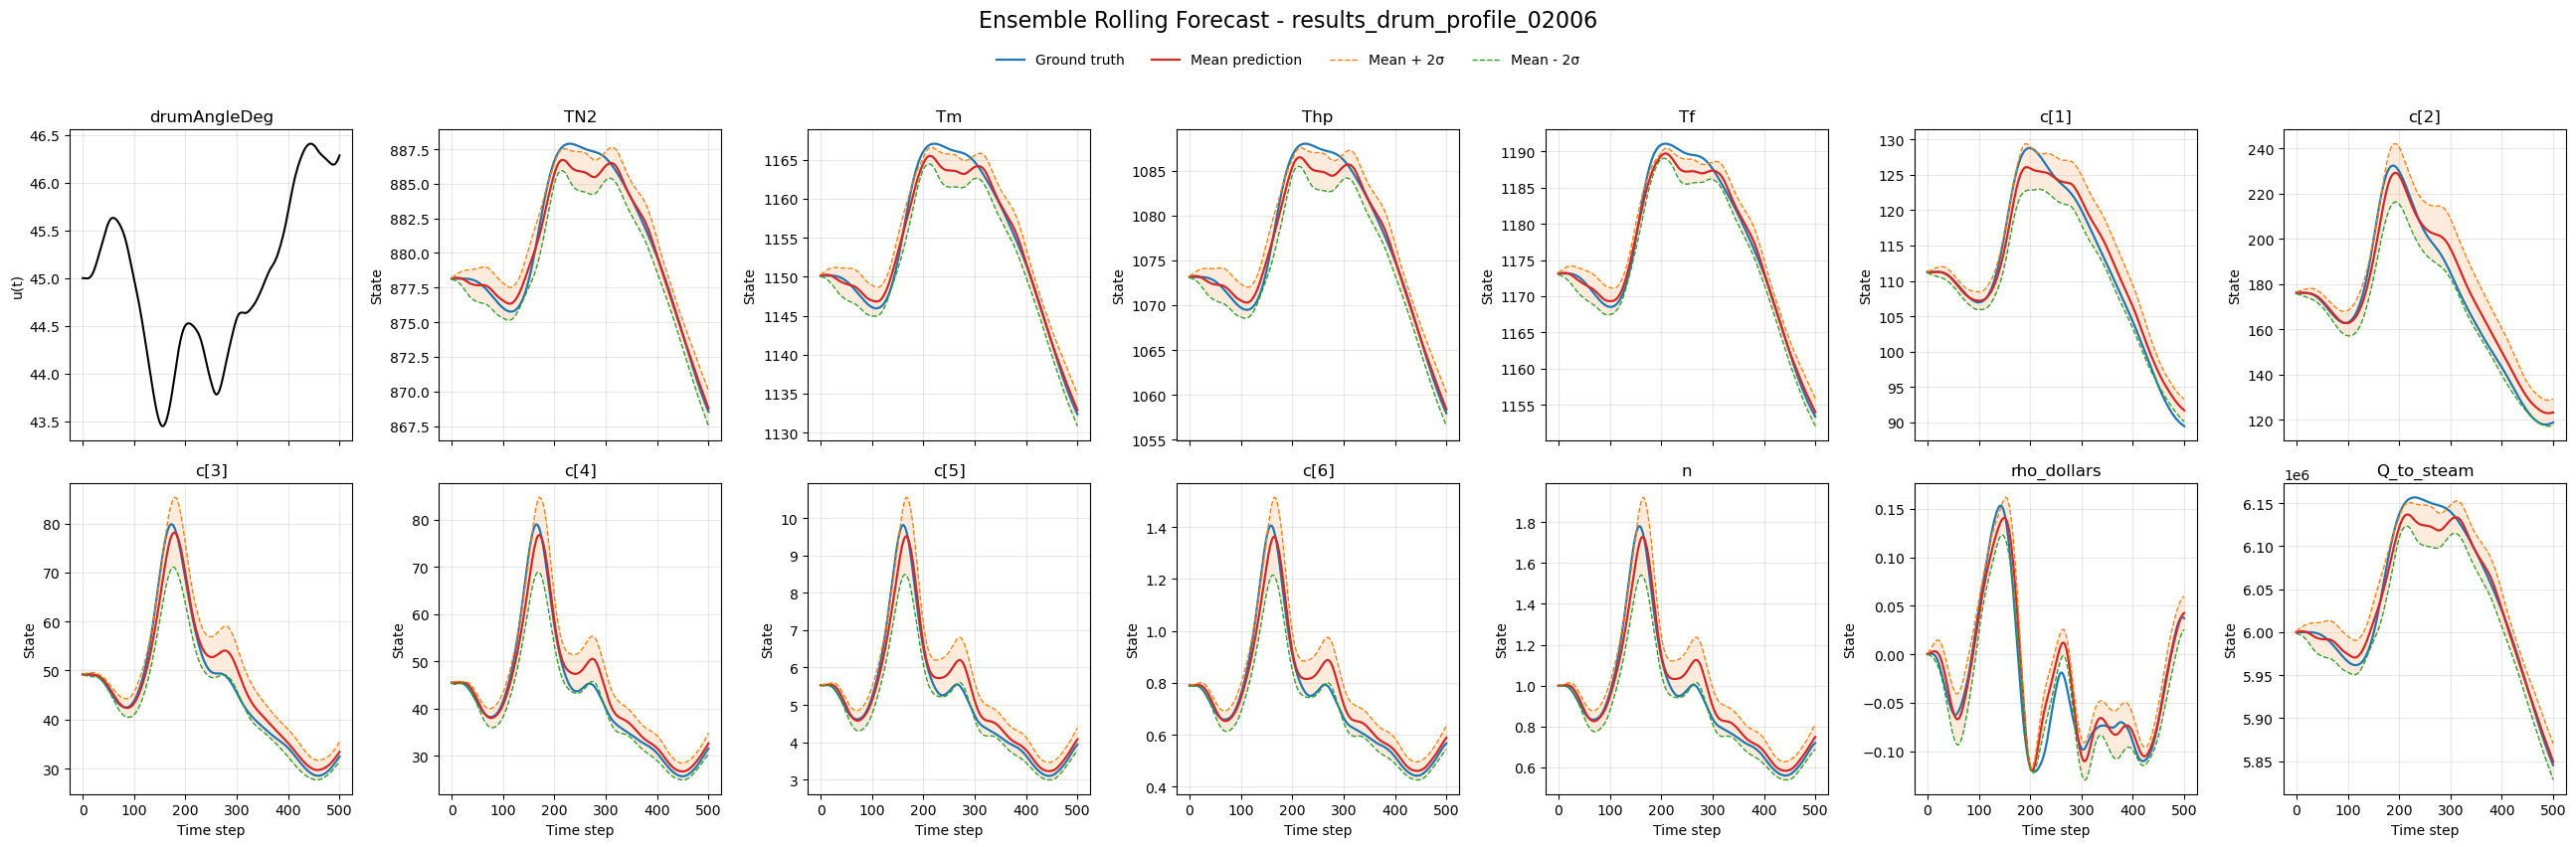

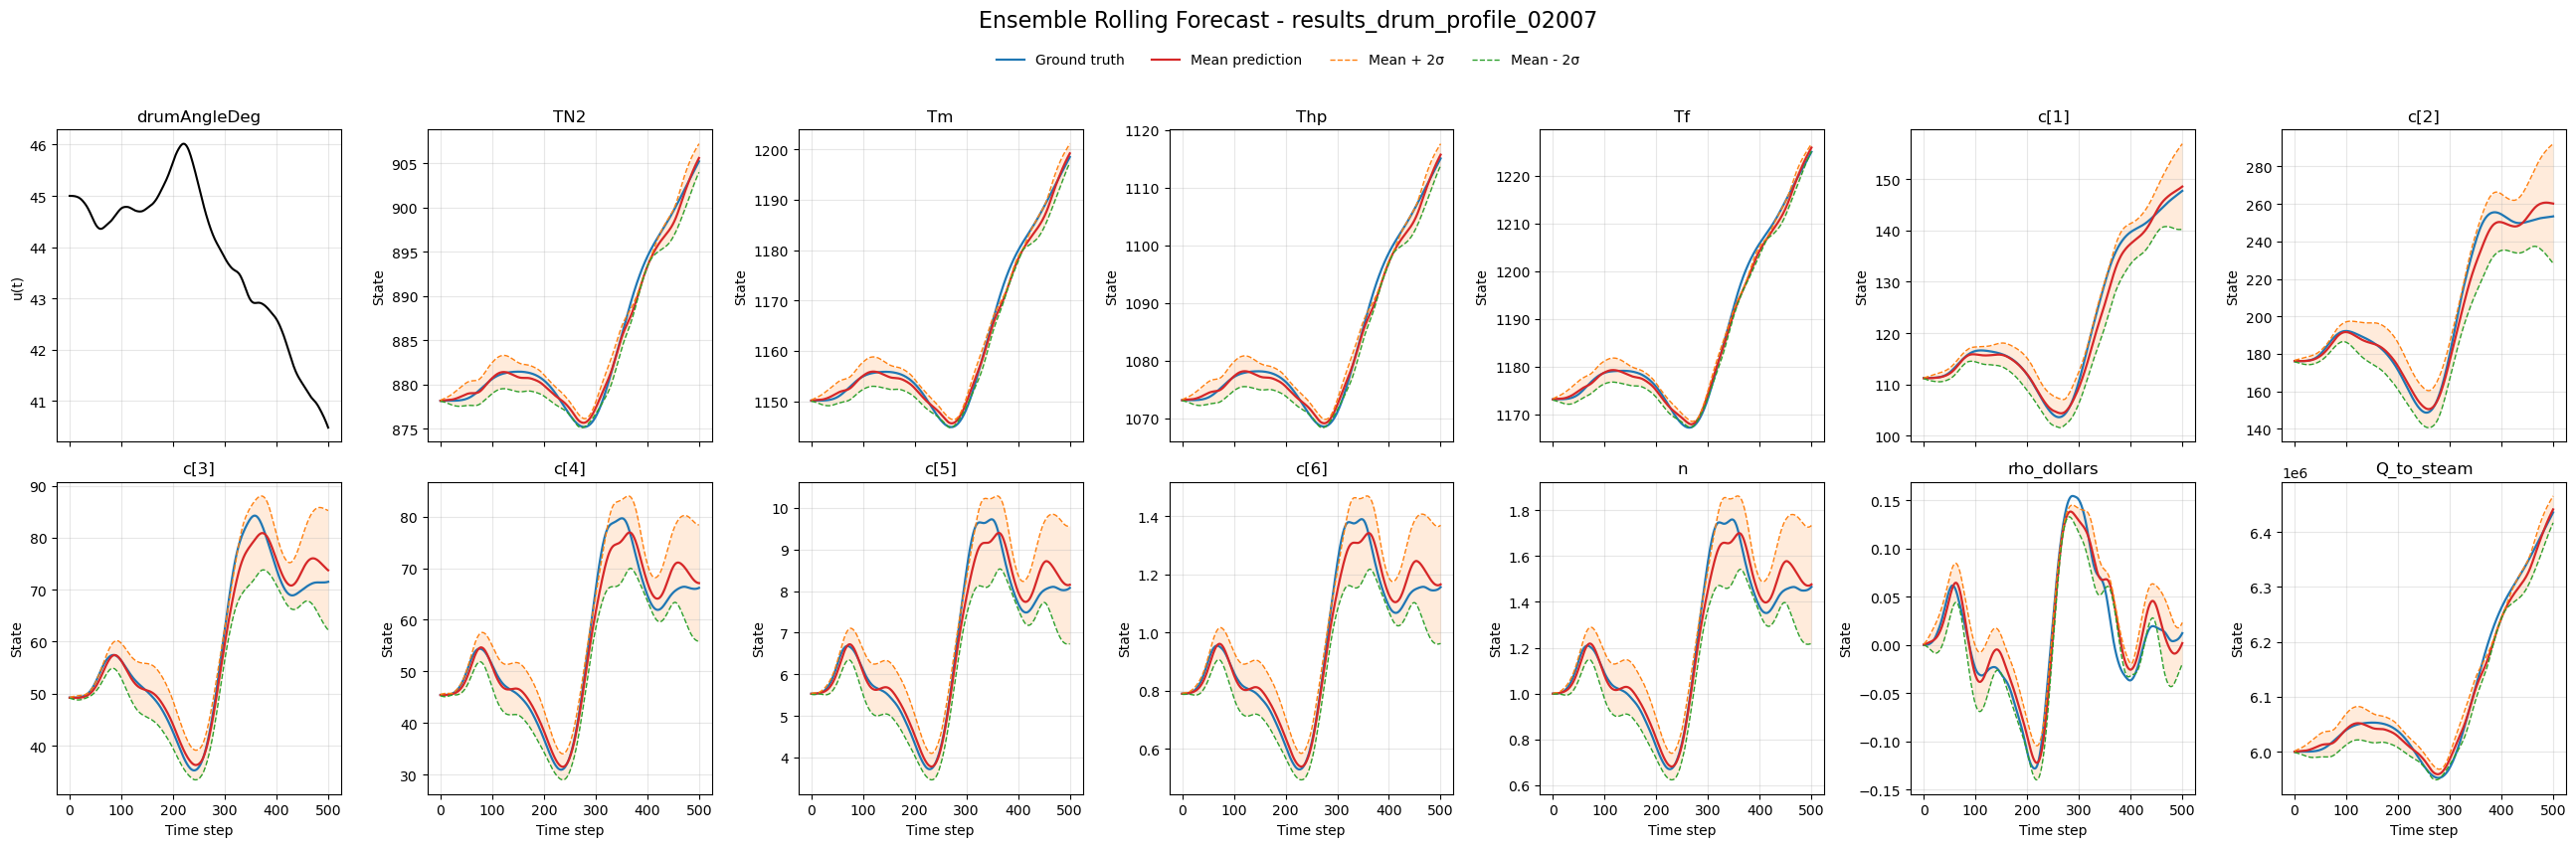

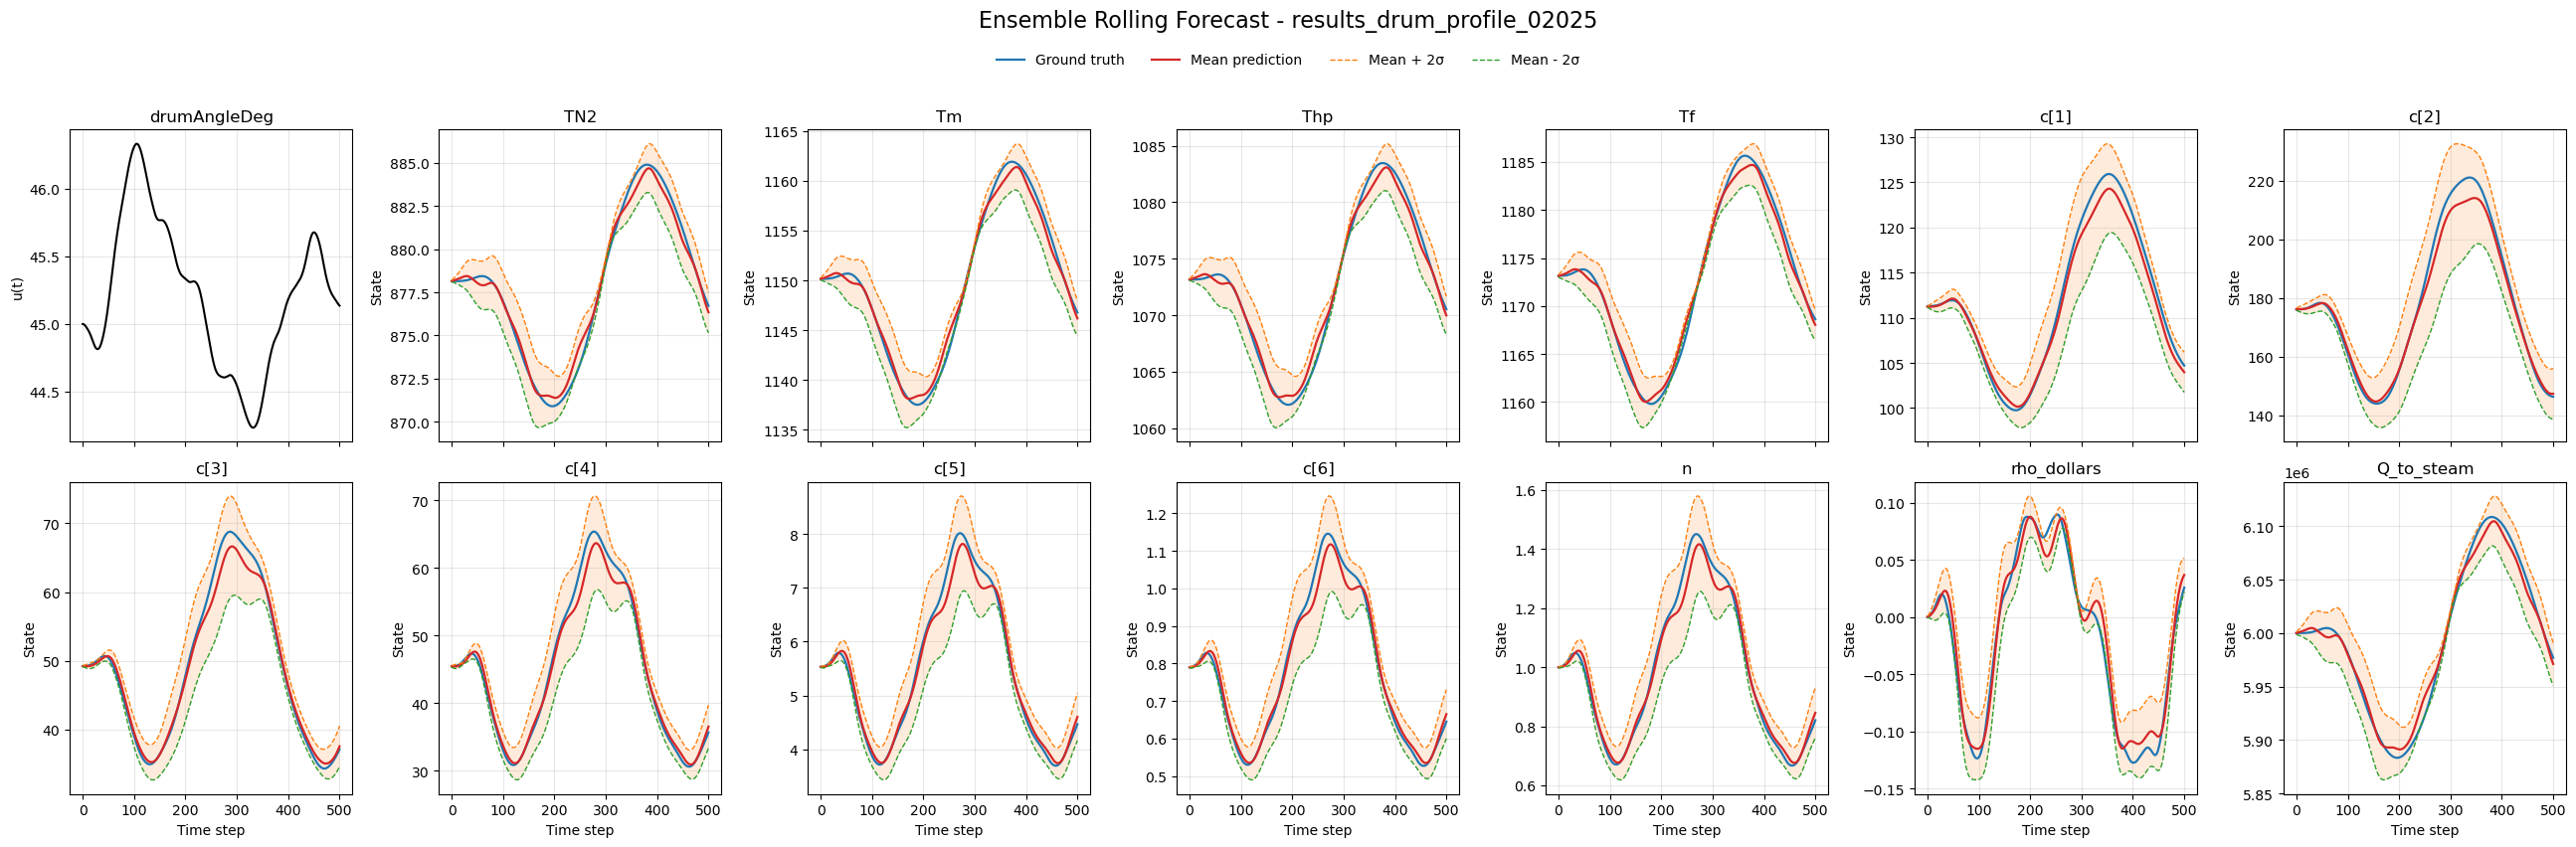

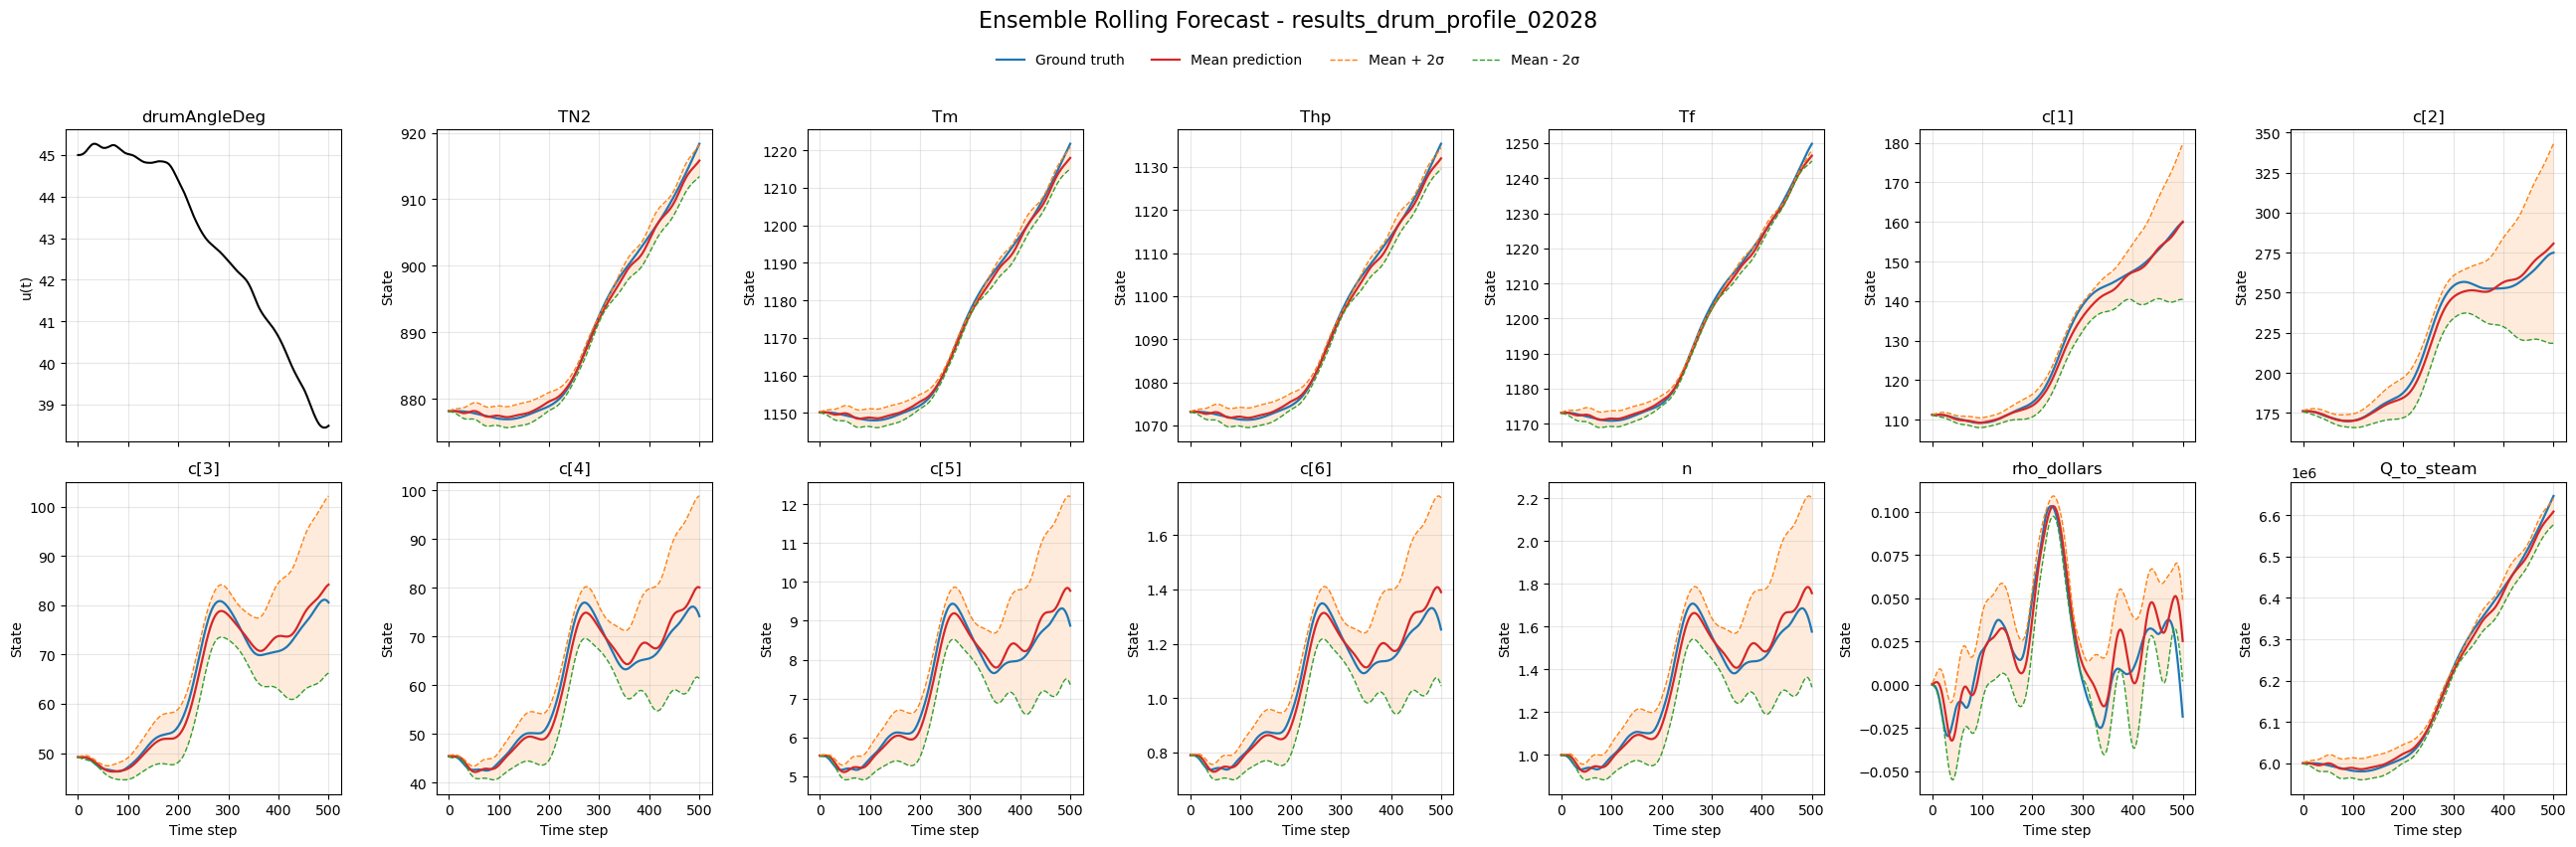

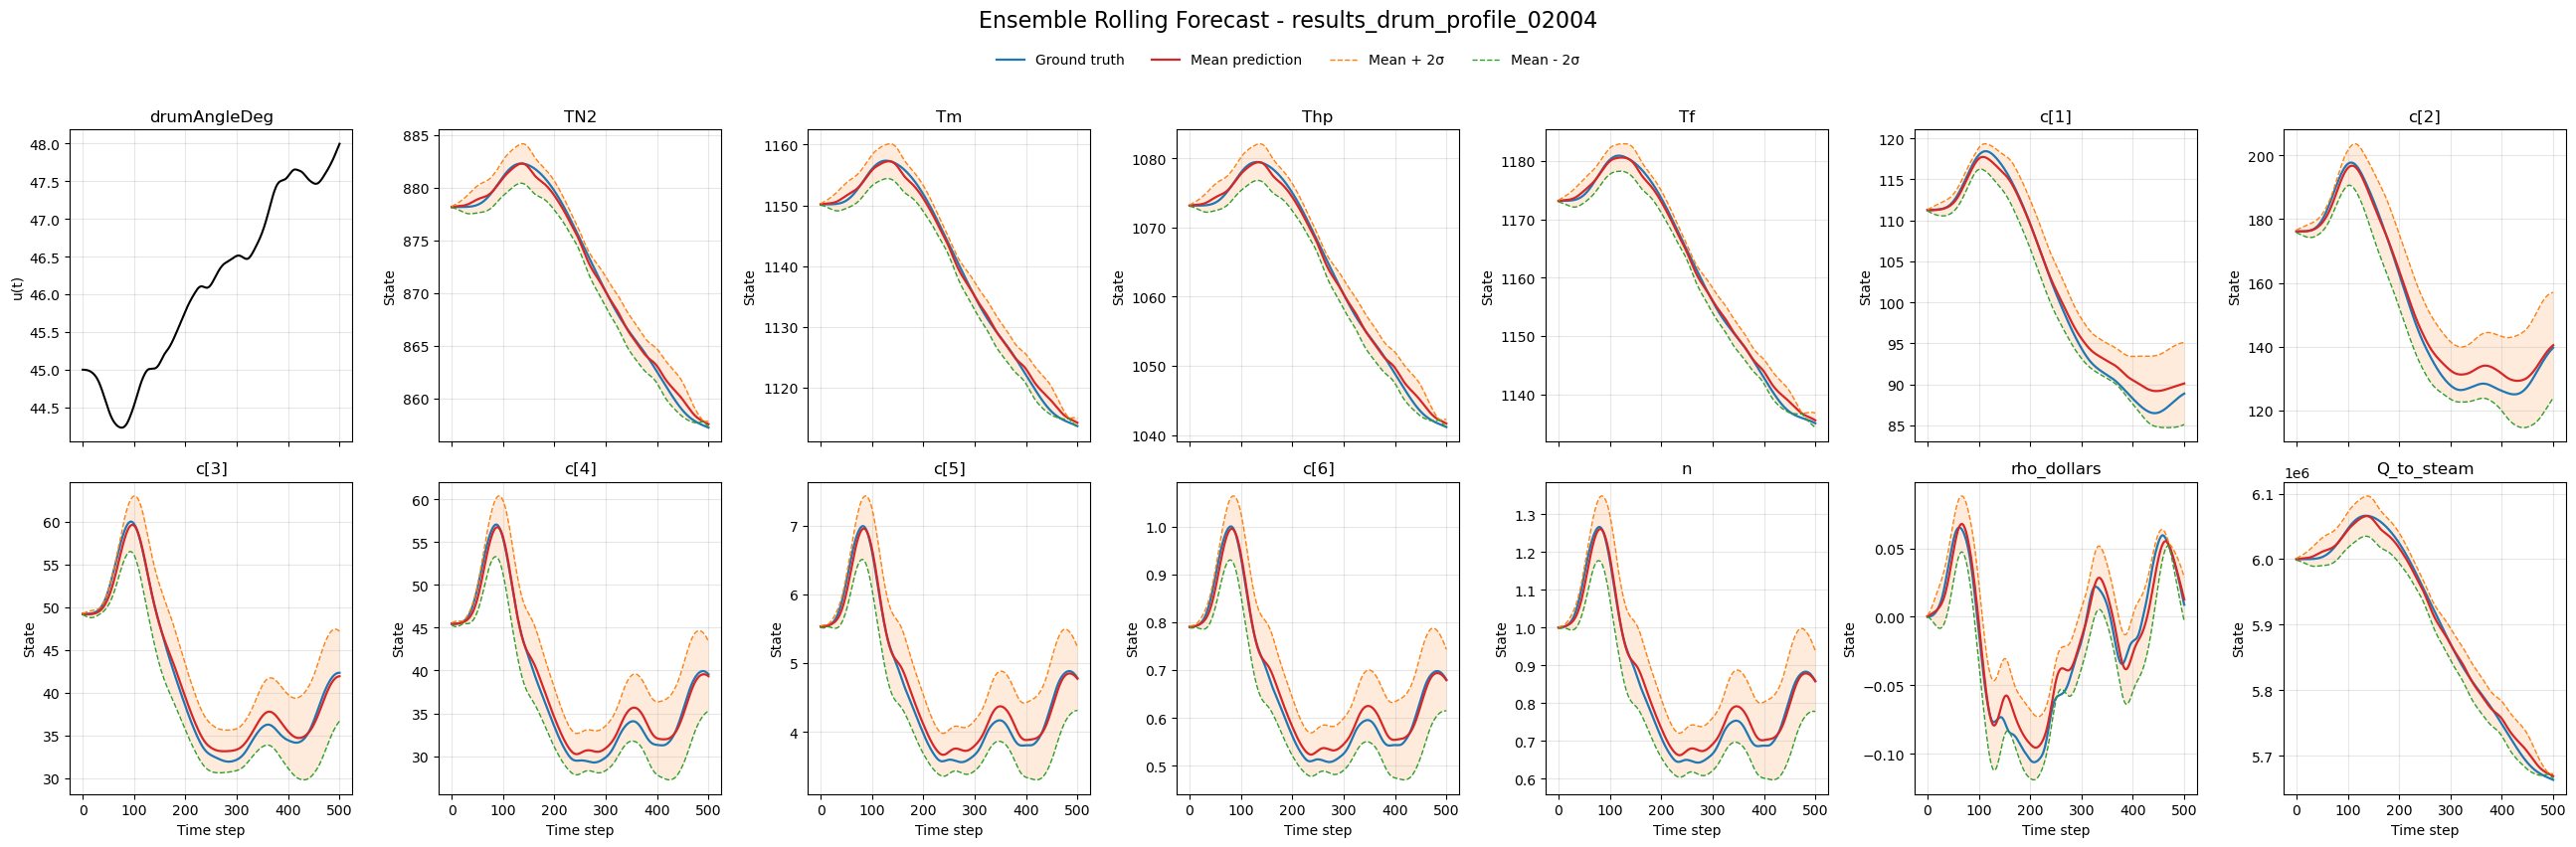

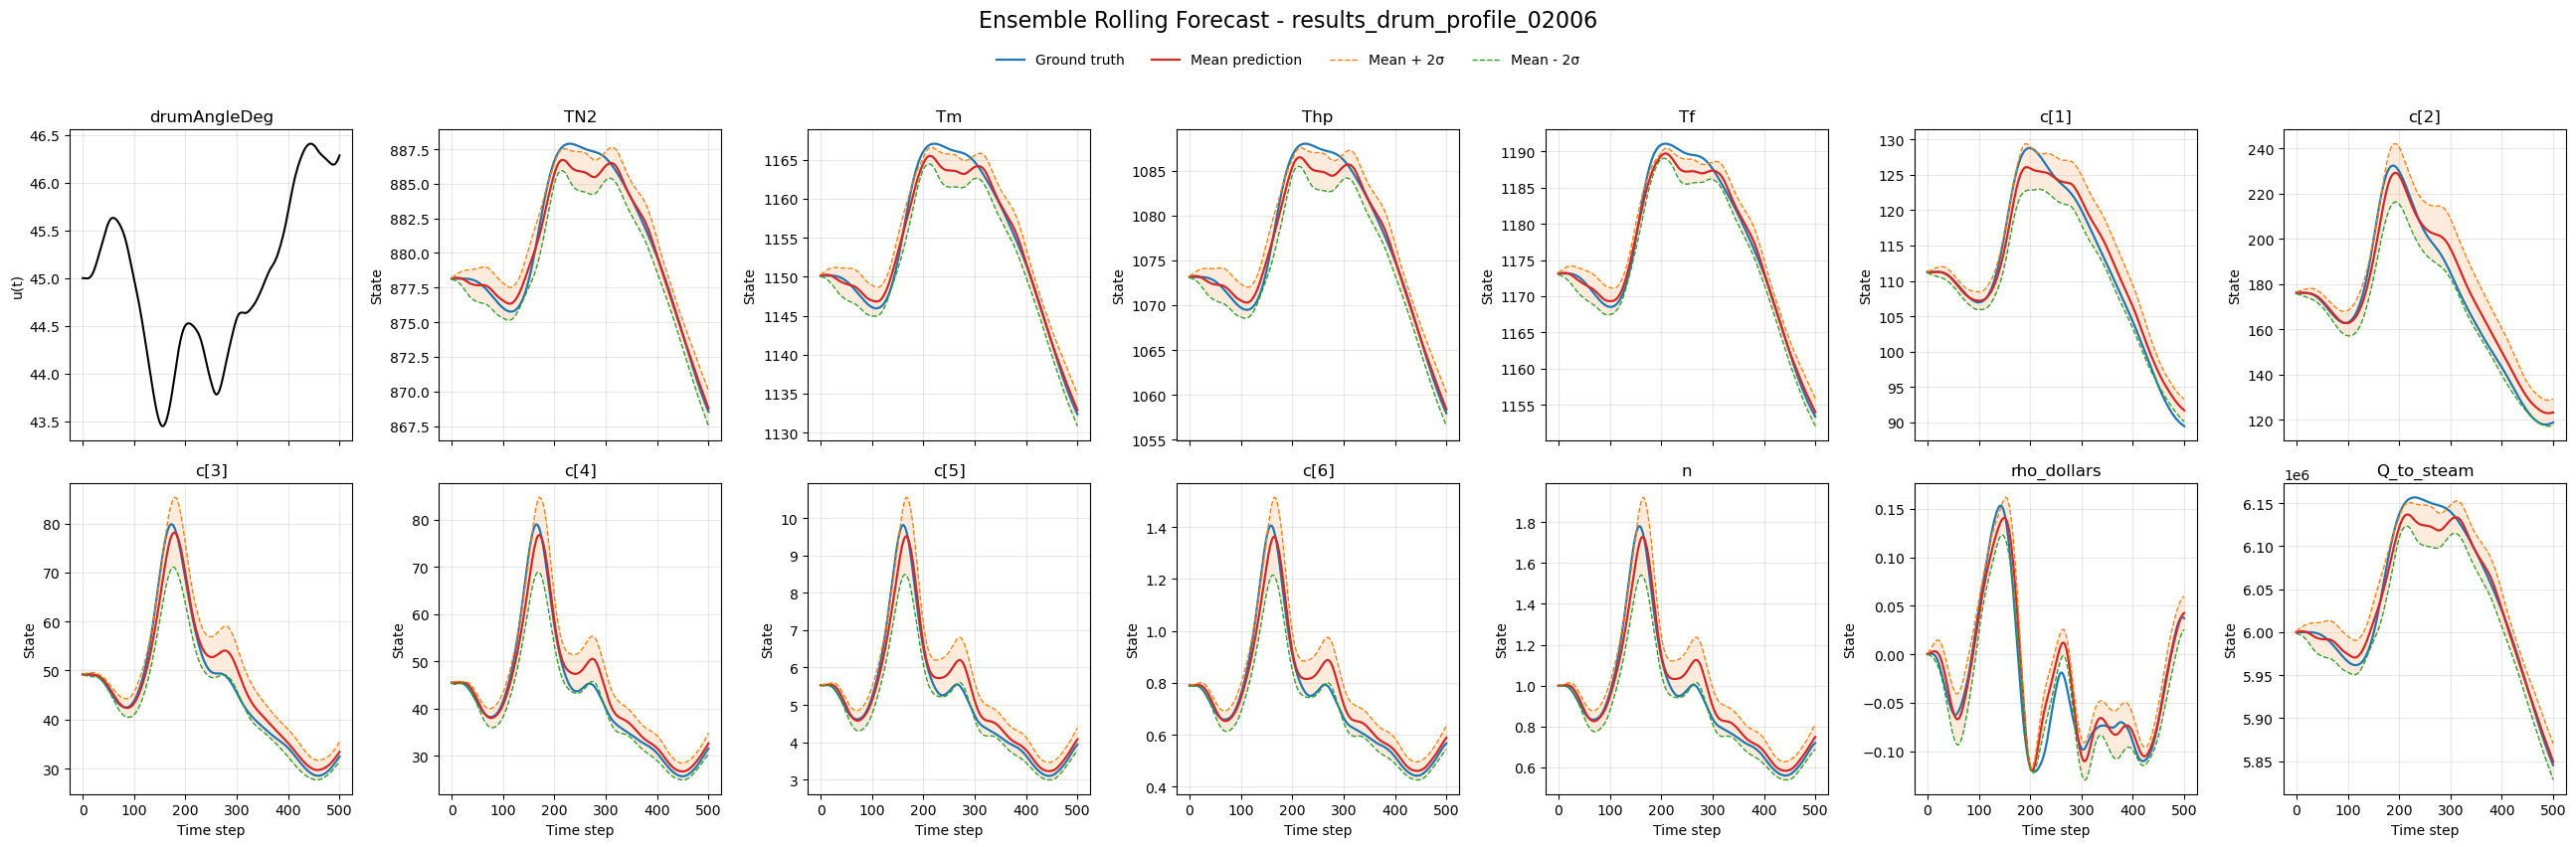

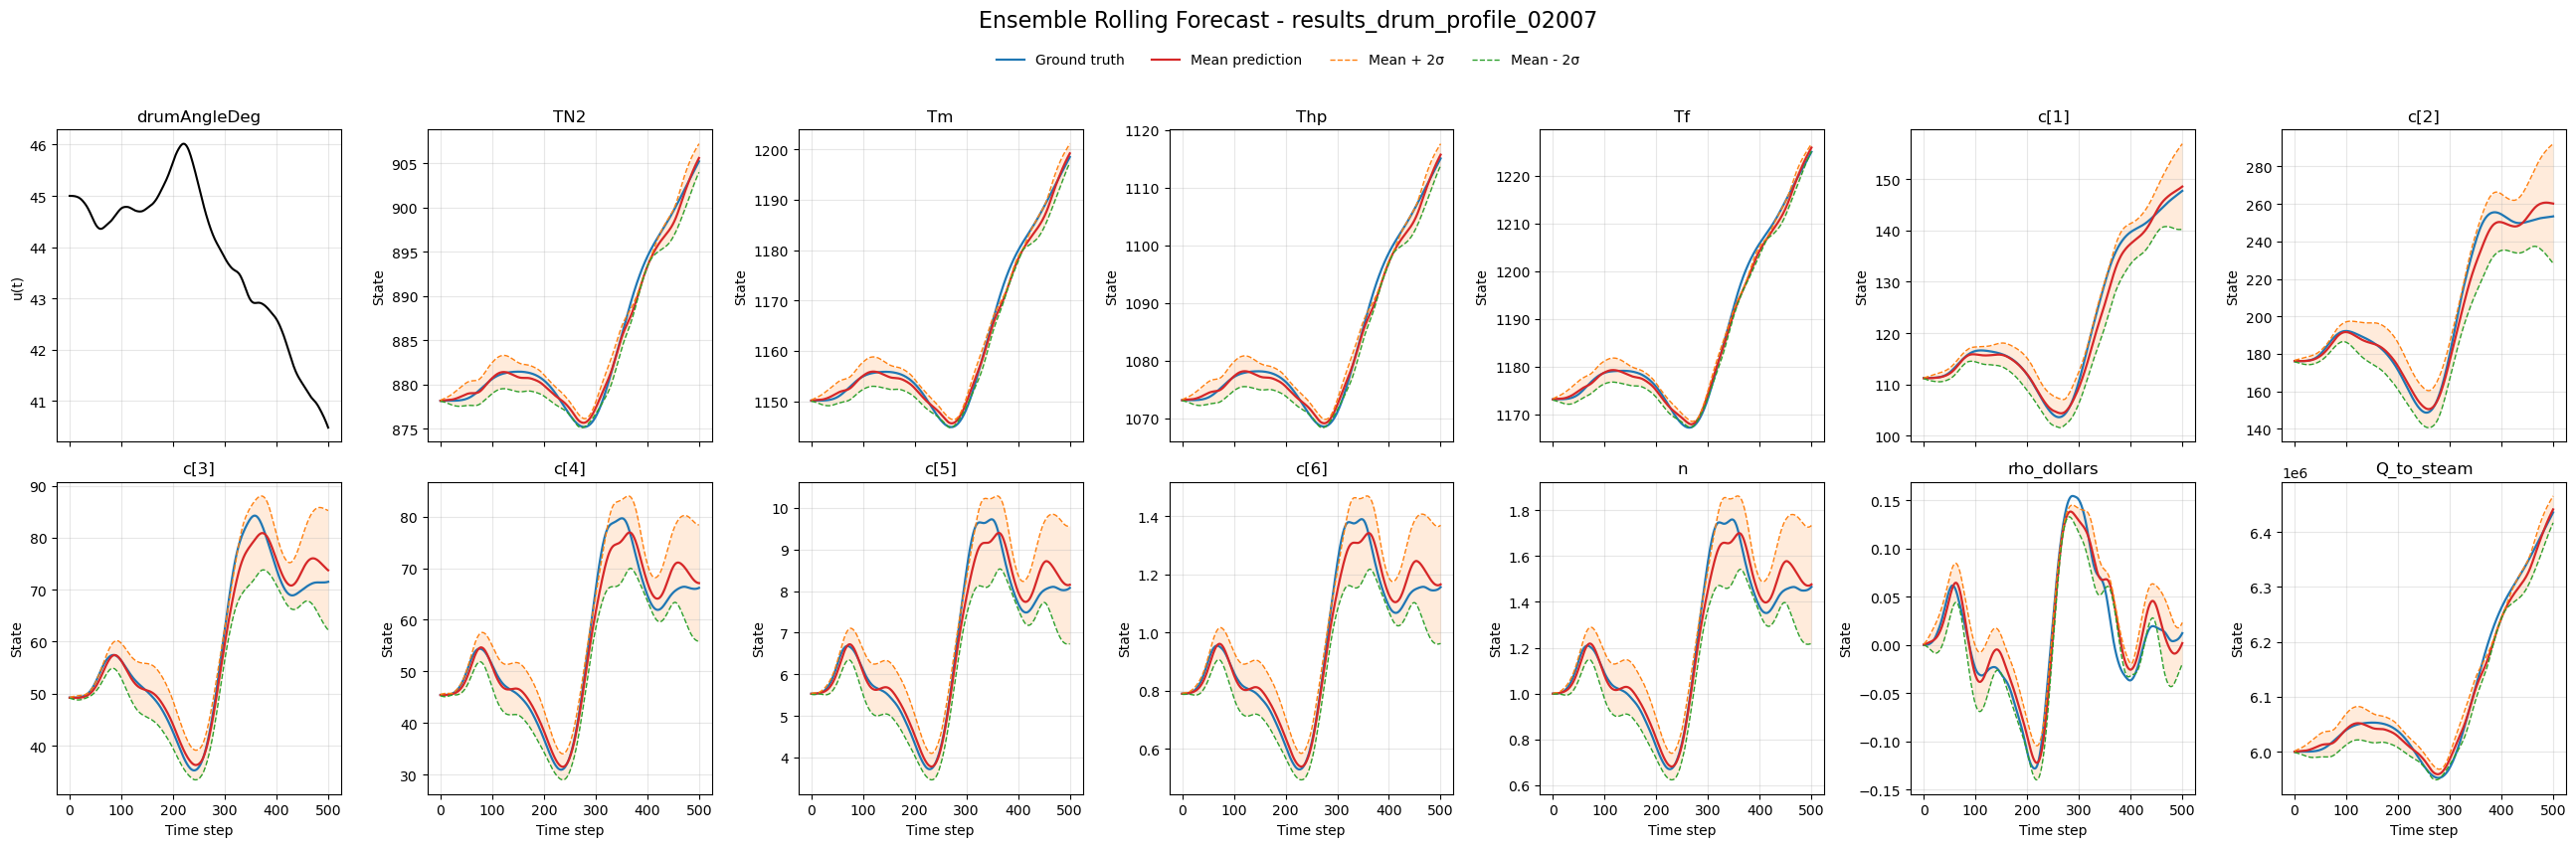

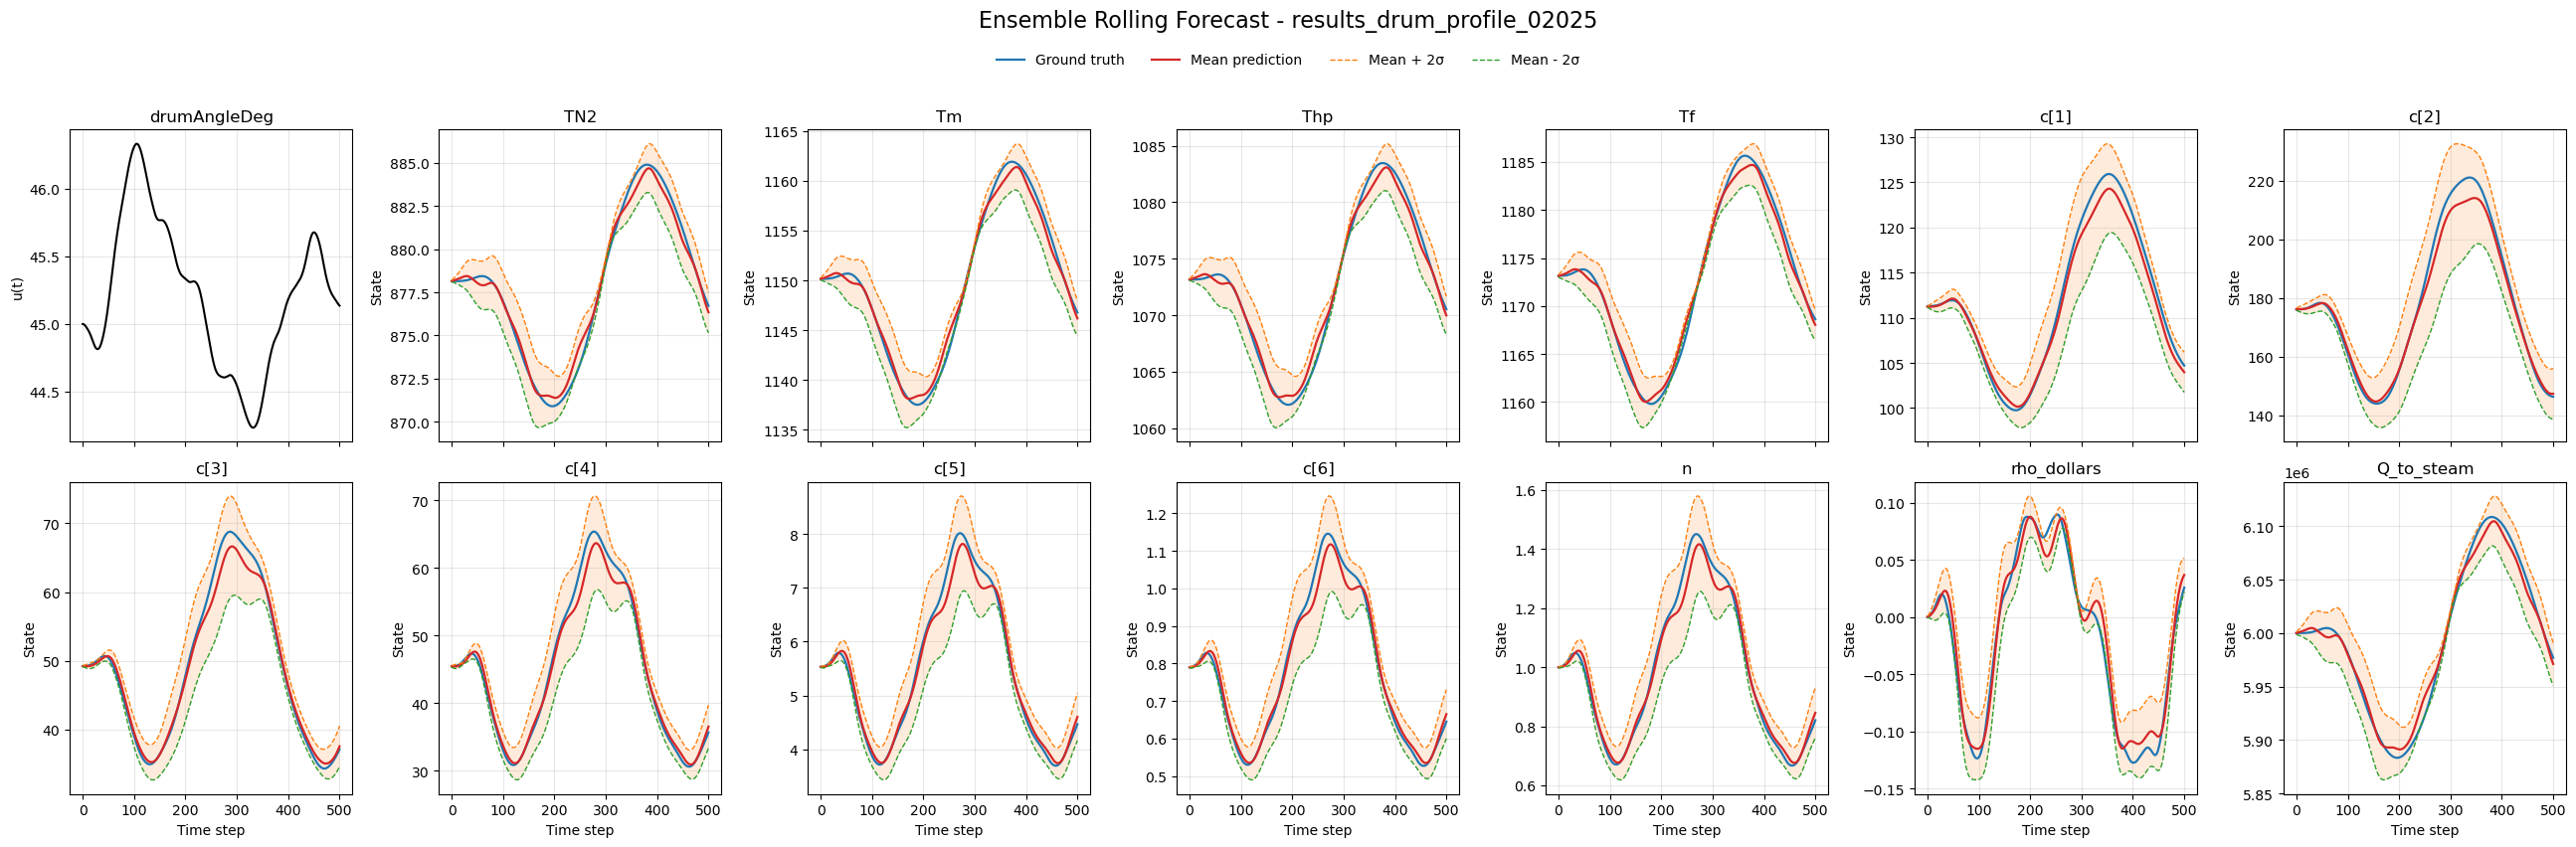

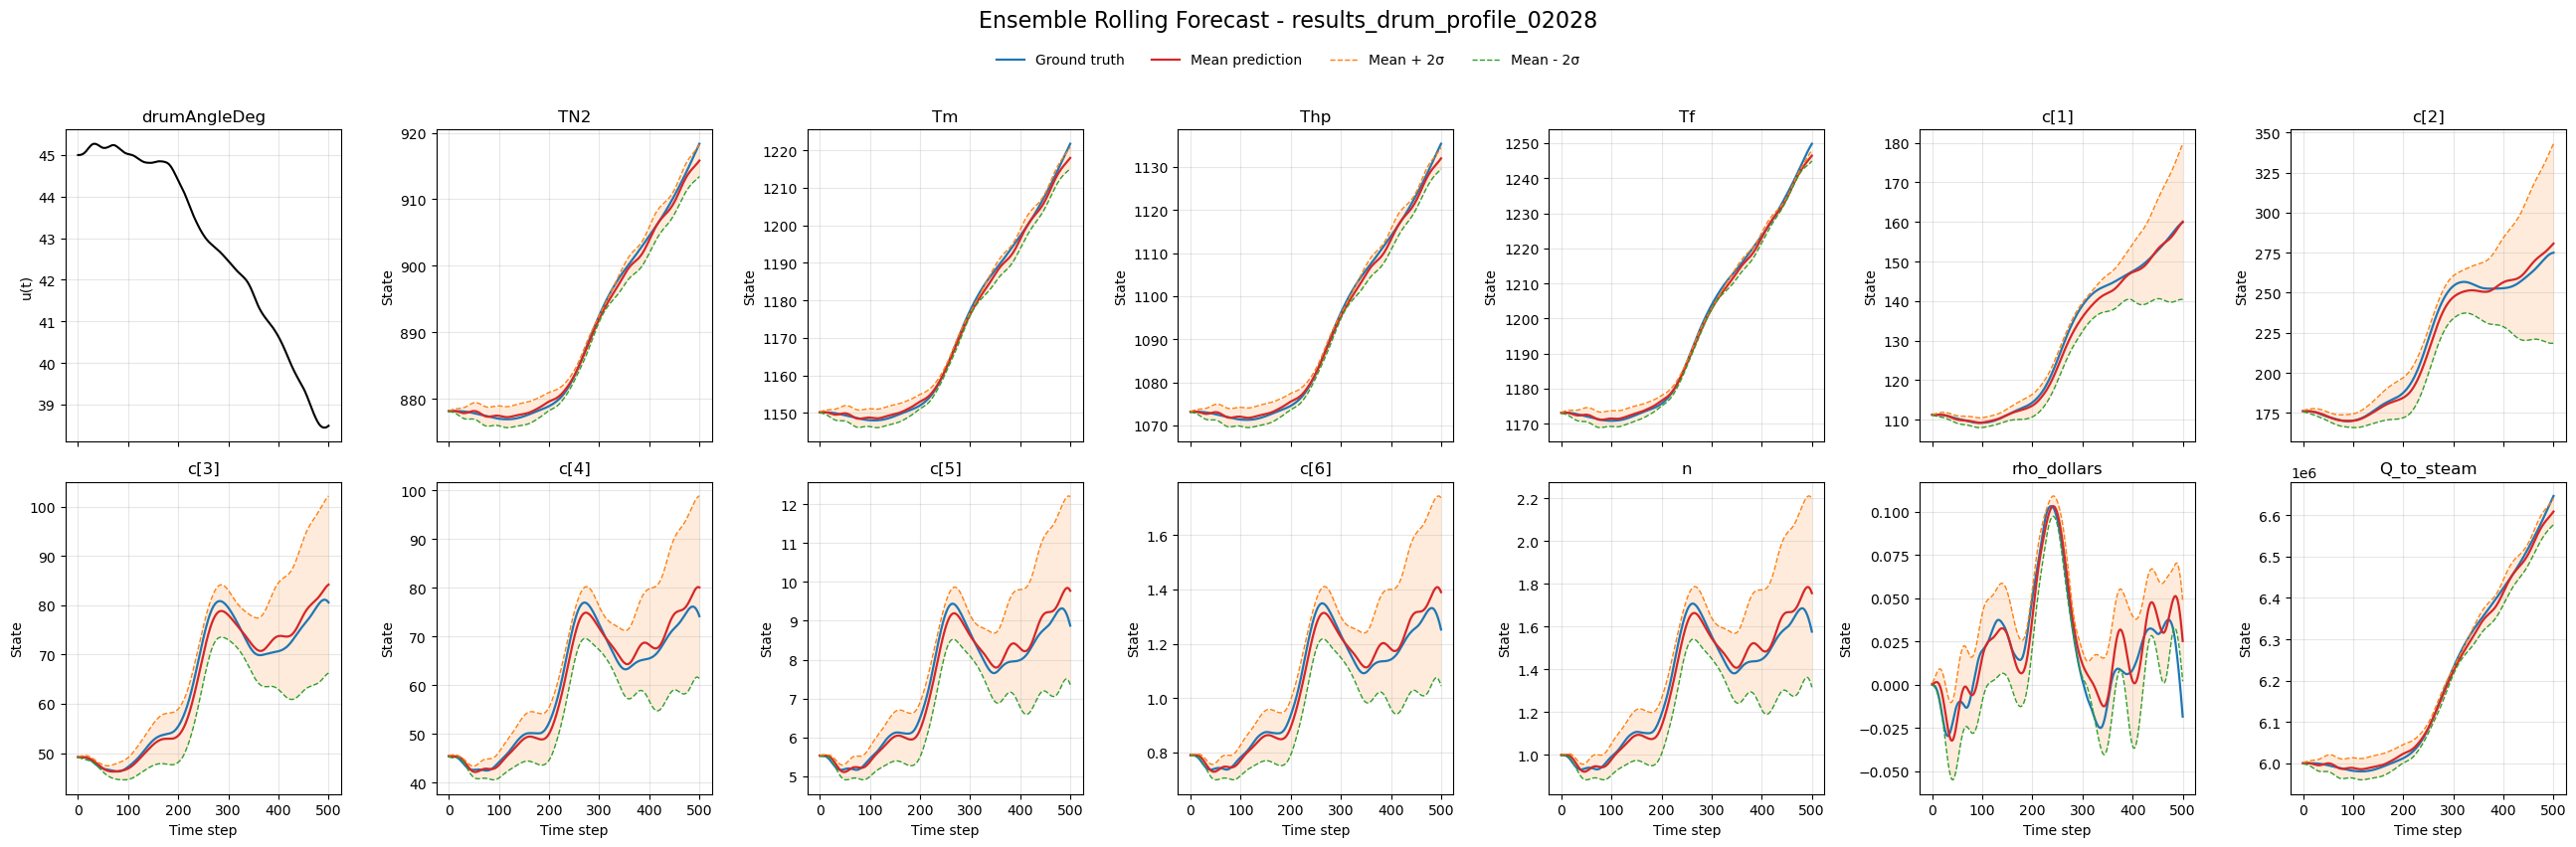

In [4]:
with h5py.File(forecast_h5_path, "r") as h5f:
    profile_names = sorted(list(h5f.keys()))

print("Num forecast profiles:", len(profile_names))
to_plot = profile_names[:5]
print("Plotting:", to_plot)

for name in to_plot:
    fig = plot_ensemble_forecast_profile_grid(
        forecast_h5_path,
        profile_name=name,
        close_figure=False,   # keep displayed in notebook
    )
    display(fig)